In [5]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages, AnyMessage
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from IPython.display import Image, display
from langgraph.graph import START, StateGraph, END


In [2]:
class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]

In [16]:
llm=ChatGroq(model="qwen-2.5-32b")

In [50]:
sys_message_title = SystemMessage(content="You are a helpful assistant, which provides a best title for the blog as per the user input ")

sys_message_blog = SystemMessage(content="You are a helpful assistant, write a detailed blog on the topic, strictly includes only content relevant to the title")

def generate_title(state):
    return {'messages':llm.invoke([sys_message_title]+state['messages']), "language": "English"}

def generate_blog(state):
    return {'messages':llm.invoke([sys_message_blog]+state['messages']), "language": "English"}

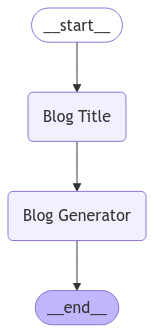

In [51]:
graph_builder = StateGraph(State)

graph_builder.add_node("Blog Title", generate_title)
graph_builder.add_node("Blog Generator", generate_blog)

graph_builder.add_edge(START,"Blog Title")
graph_builder.add_edge("Blog Title","Blog Generator")
graph_builder.add_edge("Blog Generator",END)

graph=graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
user_input = HumanMessage(content="AI agents vs Agentic AI")
message = graph.invoke({'messages': user_input})

In [53]:
message

{'messages': [HumanMessage(content='AI agents vs Agentic AI', additional_kwargs={}, response_metadata={}, id='2de1b229-1e22-4eec-8e56-022b882527b8'),
  AIMessage(content='"Understanding the Difference: AI Agents vs Agentic AI"', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 39, 'total_tokens': 52, 'completion_time': 0.065, 'prompt_time': 0.004196584, 'queue_time': 0.237027545, 'total_time': 0.069196584}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'stop', 'logprobs': None}, id='run-814e94fb-e191-4491-bff9-f9dbc5e14aae-0', usage_metadata={'input_tokens': 39, 'output_tokens': 13, 'total_tokens': 52}),
  AIMessage(content='### Understanding the Difference: AI Agents vs Agentic AI\n\nArtificial Intelligence (AI) has become an integral part of our daily lives, from virtual assistants to autonomous vehicles. Within the broad spectrum of AI, two terms often surface: AI Agents and Agentic AI. While t

In [54]:
for m in message['messages']:
    m.pretty_print()

================================ Human Message =================================

AI agents vs Agentic AI
================================== Ai Message ==================================

"Understanding the Difference: AI Agents vs Agentic AI"
================================== Ai Message ==================================

### Understanding the Difference: AI Agents vs Agentic AI

Artificial Intelligence (AI) has become an integral part of our daily lives, from virtual assistants to autonomous vehicles. Within the broad spectrum of AI, two terms often surface: AI Agents and Agentic AI. While these terms might sound similar, they refer to distinct concepts in the realm of AI. Let’s explore what each term means and how they differ from each other.

#### AI Agents

AI Agents are computer programs designed to perform specific tasks autonomously or semi-autonomously. These agents operate within a given environment and are programmed to interact with the environment to achieve predefined go